folder      : C:\Users\paraj\Documents\bayesian-die-swell-main\datas\infer-oldroyd-rom1\giesekus_lam_1_beta_0p5_alpha_0p01
points      : 247 (thin=1)
curve noise : 2.0% of disp, sigma 0.002621 (realized 0.002398)


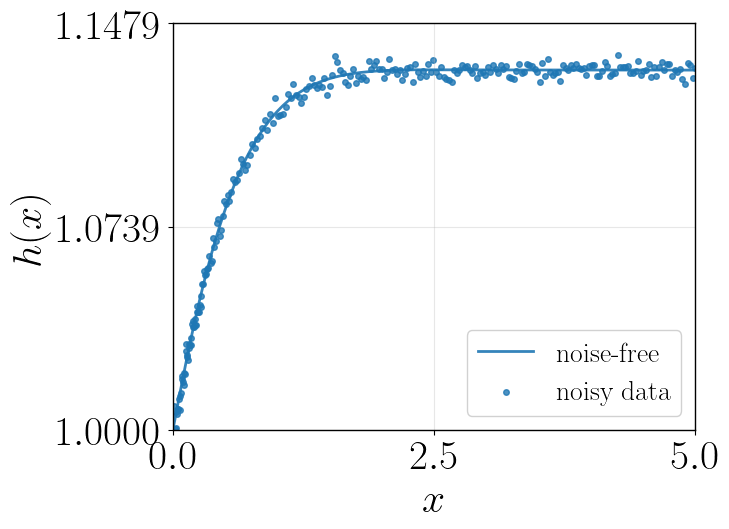

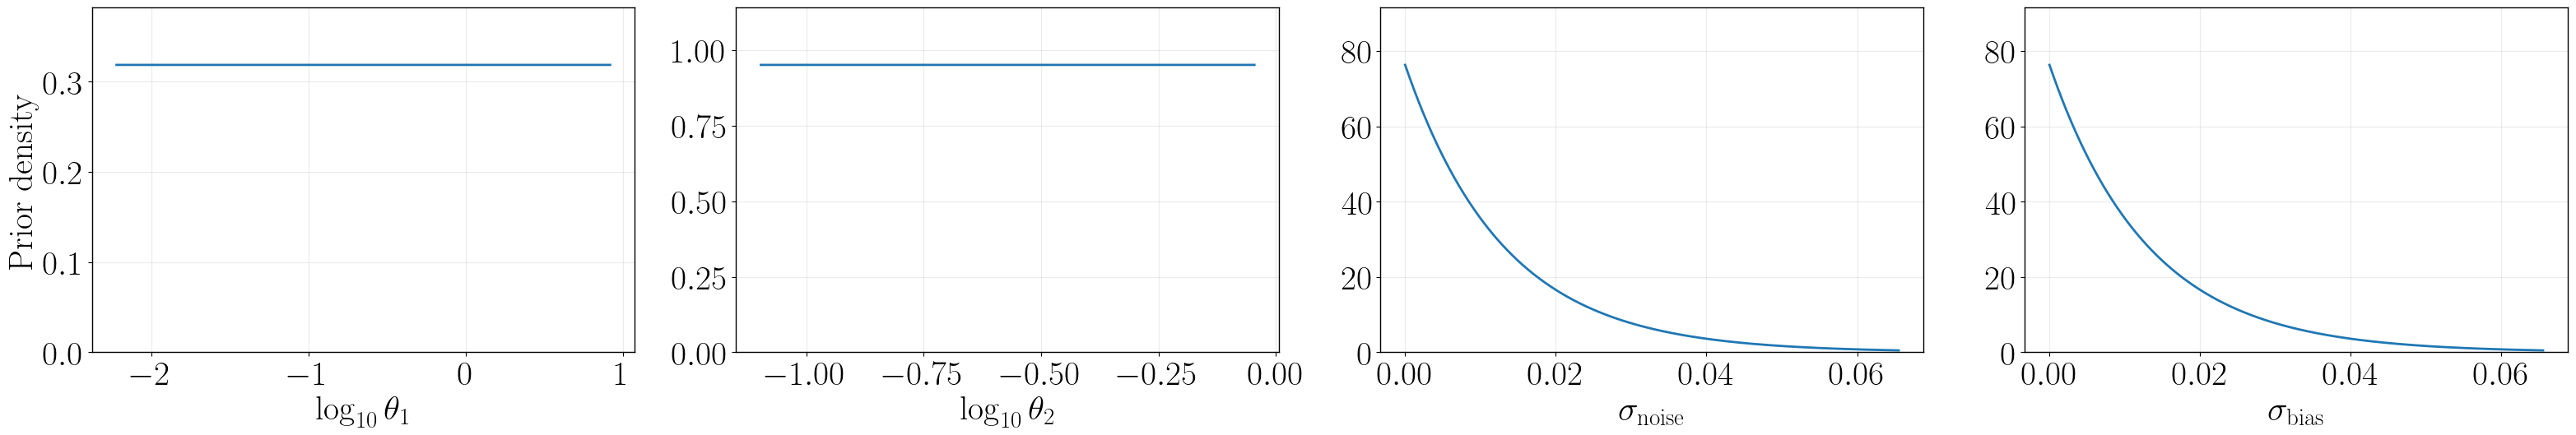

curve4_y GPR on (theta1, theta2), 120 curves: 0.686**2 * RBF(length_scale=[0.0614, 0.391])
parametrize bounds: theta1 (0.005999999999999998, 8.280000000000001), theta2 (0.08, 0.9), implied lambda (0.06, 9.0)
Initial walkers (first 10 of 10, physical space):
          theta1        theta2   sigma_noise    sigma_bias
          1.9041       0.47898      0.011608      0.014161
         0.18228       0.29192      0.014594      0.015149
        0.017924          0.73      0.013879     0.0099664
           1.493       0.14856      0.011064      0.017267
        0.070964       0.73803      0.013389      0.014606
          4.6639       0.17731     0.0078566      0.017849
         0.54384       0.49357      0.016716      0.016235
           0.437       0.14568      0.010572     0.0050902
         0.12086       0.12625      0.013481       0.01799
        0.062603       0.30664      0.012402     0.0099293


 87%|████████▋ | 10421/12000 [00:15<00:02, 555.36it/s]

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    parametrize = True,   
    train_data_rels=["datas/oldroyd-rom1"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (0.06, 9.0),
    beta_bounds = (0.08, 0.9),
    sigma_noise_percent=2.0,
    thin=1,
    sigma_bias=True,
    constrained_model_error=True,
    l_bias = 0.51)

model.load_data(filename="datas/infer-oldroyd-rom1/giesekus_lam_1_beta_0p5_alpha_0p01/curve4_y.txt")
model.plot_data()
model.plot_prior()
model.build_rom()
model.run_mcmc(nwalkers=10, nsteps=60000, warmup_fraction=0.1, burn_fraction=0.5)
model.compute_N1(U_avg = 0.1)
model.plot_corner_all()
model.plot_trace_all()
model.plot_posterior_predictive()